# Rag 파이프라인 구축
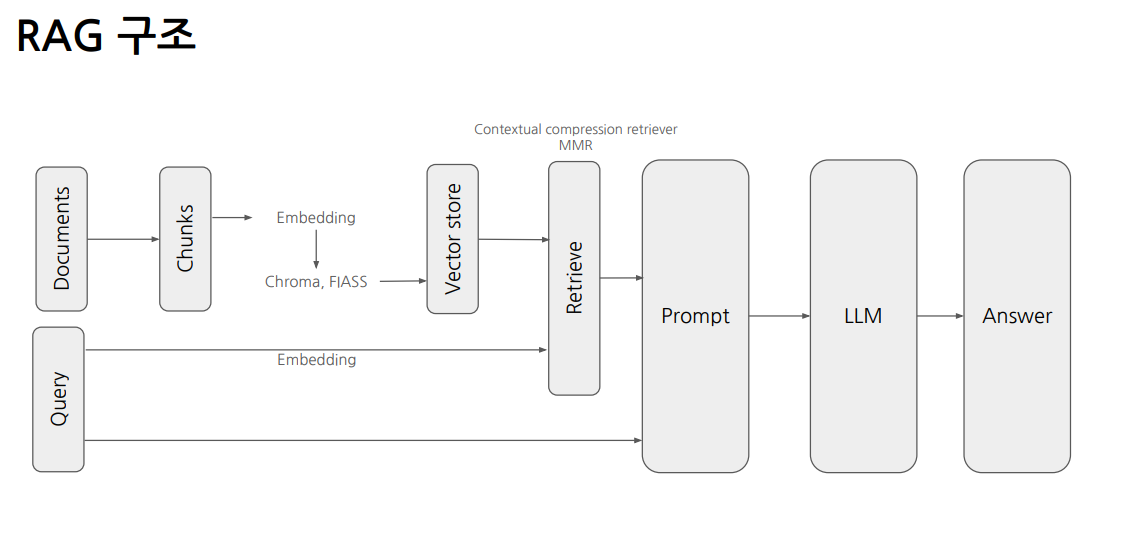

## 환경설정

In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
import os
os.environ["LANGCHAIN_TRACING_V2"] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = "https://api.smith.langchain.com"
os.environ['LANGCHAIN_PROJECT'] = 'sesac'

## Documents 읽어오기

In [5]:
from langchain_community.document_loaders import WebBaseLoader

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
url = 'https://ko.wikipedia.org/wiki/위키백과:정책과_지침'

In [7]:
loader = WebBaseLoader(url)

In [8]:
docs = loader.load()

In [9]:
len(docs)

1

In [10]:
docs

[Document(metadata={'source': 'https://ko.wikipedia.org/wiki/위키백과:정책과_지침', 'title': '위키백과:정책과 지침 - 위키백과, 우리 모두의 백과사전', 'language': 'ko'}, page_content='\n\n\n\n위키백과:정책과 지침 - 위키백과, 우리 모두의 백과사전\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n본문으로 이동\n\n\n\n\n\n\n\n주 메뉴\n\n\n\n\n\n주 메뉴\n사이드바로 이동\n숨기기\n\n\n\n\t\t둘러보기\n\t\n\n\n대문최근 바뀜요즘 화제임의의 문서로\n\n\n\n\n\n\t\t사용자 모임\n\t\n\n\n사랑방사용자 모임관리 요청\n\n\n\n\n\n\t\t편집 안내\n\t\n\n\n소개도움말정책과 지침질문방\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n검색\n\n\n\n\n\n\n\n\n\n\n\n검색\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n보이기\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n기부\n\n계정 만들기\n\n로그인\n\n\n\n\n\n\n\n\n개인 도구\n\n\n\n\n\n기부 계정 만들기 로그인\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n목차\n사이드바로 이동\n숨기기\n\n\n\n\n처음 위치\n\n\n\n\n\n1\n최상위 정책\n\n\n\n\n\n\n\n\n2\n\'정책과 지침\'이란?\n\n\n\n\n\n\n\n\n3\n준수\n\n\n\n\n\n\n\n\n4\n집행\n\n\n\n\n\n\n\n\n5\n문서 내용\n\n\n\n\n\n\n\n\n6\n정책과 지침은 백과사전의 일부가 아닙니다\n\n\n\n\n\n\n\n\n7\n채택 과정\n\n\n\n\n채택 과정 하위섹션 토글하기\n\n\n\n\n\n7.1\n제안과 채택\n\n\n\

In [11]:
docs[0].metadata

{'source': 'https://ko.wikipedia.org/wiki/위키백과:정책과_지침',
 'title': '위키백과:정책과 지침 - 위키백과, 우리 모두의 백과사전',
 'language': 'ko'}

In [12]:
docs[0].page_content[:100]

'\n\n\n\n위키백과:정책과 지침 - 위키백과, 우리 모두의 백과사전\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n본문으로 이동\n\n\n\n\n\n\n\n주 메뉴\n\n\n\n\n\n주 메뉴\n사이드바로 이'

In [13]:
main_content = docs[0].page_content

In [14]:
main_content = main_content.replace("\n", "").replace('\t', ' ')


In [15]:
main_content

'위키백과:정책과 지침 - 위키백과, 우리 모두의 백과사전본문으로 이동주 메뉴주 메뉴사이드바로 이동숨기기  둘러보기 대문최근 바뀜요즘 화제임의의 문서로  사용자 모임 사랑방사용자 모임관리 요청  편집 안내 소개도움말정책과 지침질문방검색검색보이기기부계정 만들기로그인개인 도구기부 계정 만들기 로그인목차사이드바로 이동숨기기처음 위치1최상위 정책2\'정책과 지침\'이란?3준수4집행5문서 내용6정책과 지침은 백과사전의 일부가 아닙니다7채택 과정채택 과정 하위섹션 토글하기7.1제안과 채택7.2내용 변경7.2.1실질적인 변경7.3격하8같이 보기9외부 링크목차 토글위키백과:정책과 지침115개 언어Afrikaansአማርኛअंगिकाالعربيةالدارجةمصرىঅসমীয়াАварAzərbaycancaتۆرکجهБашҡортсаBoarischБеларускаяБеларуская (тарашкевіца)БългарскиभोजपुरीBanjarবাংলাBrezhonegBosanskiCatalàНохчийнکوردیČeštinaCymraegDanskDeutschΕλληνικάEnglishEsperantoEspañolEuskaraفارسیSuomiFrançaisNordfriiskGaeilge贛語GalegoگیلکیBahasa Hulontaloעבריתहिन्दीHrvatskiHornjoserbsceMagyarՀայերենInterlinguaBahasa IndonesiaГӀалгӀайÍslenskaItaliano日本語ქართულიQaraqalpaqshaҚазақшаಕನ್ನಡکٲشُرKurdîКыргызчаLëtzebuergeschລາວमैथिलीMinangkabauМакедонскиമലയാളംМонголBahasa Melayuမြန်မာဘာသာمازِرونیNapulitanoPlattdüütschनेपालीNederlandsNorsk nynorskNorsk bokmålDiné bizaadPolskiپښتوPortuguêsRomani čhibRomânăРусскийSicilianuSc

## Chunk

In [16]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [17]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
splits = text_splitter.split_documents(docs) # split_text 도 있음 : 단일 문자열 분리, 메타 데이터 사용 하지 않음

In [18]:
len(splits)

19

In [19]:
splits[10].page_content

'제안과 채택\n\xa0백:아님 §\xa0관료주의  문서를 참고하십시오. 단축백:제안\n제안 문서란 정책과 지침으로 채택하자고 의견을 묻는 문서이나 아직 위키백과 내에 받아들여지는 원칙으로 확립되지는 않은 문서입니다. {{제안}} 틀을 붙여 공동체 내에서 정책이나 지침으로 채택할 지 의견을 물을 수 있습니다. 제안 문서는 정책과 지침이 아니므로 아무리 실제 있는 정책이나 지침을 요약하거나 인용해서 다른 문서에 쓴다고 해도 함부로 정책이나 지침 틀을 붙여서는 안 됩니다.\n\'제안\'은 완전 새로운 원칙이라기보다, 기존의 불문율이나 토론 총의의 문서를 통한 구체화에 가깝습니다. 많은 사람들이 쉽게 제안을 받아들이도록 하기 위해서는, 기초적인 원칙을 우선 정하고 기본 틀을 짜야 합니다. 정책과 지침의 기본 원칙은 "왜 지켜야 하는가?", "어떻게 지켜야 하는가?" 두 가지입니다. 특정 원칙을 정책이나 지침으로 확립하기 위해서는 우선 저 두 가지 물음에 성실하게 답하는 제안 문서를 작성해야 합니다.\n좋은 아이디어를 싣기 위해 사랑방이나 관련 위키프로젝트에 도움을 구해 피드백을 요청할 수 있습니다. 이 과정에서 공동체가 어느 정도 받아들일 수 있는 원칙이 구체화됩니다. 많은 이와의 토론을 통해 공감대가 형성되고 제안을 개선할 수 있습니다.\n정책이나 지침은 위키백과 내의 모든 편집자들에게 적용되는 원칙이므로 높은 수준의 총의가 요구됩니다. 제안 문서가 잘 짜여졌고 충분히 논의되었다면, 더 많은 공동체의 편집자와 논의를 하기 위해 승격 제안을 올려야 합니다. 제안 문서 맨 위에 {{제안}}을 붙여 제안 안건임을 알려주고, 토론 문서에 {{의견 요청}}을 붙인 뒤 채택 제안에 관한 토론 문단을 새로 만들면 됩니다. 많은 편집자들에게 알리기 위해 관련 내용을 {{위키백과 소식}}에 올리고 사랑방에 이를 공지해야 하며, 합의가 있을 경우 미디어위키의 sitenotice(위키백과 최상단에 노출되는 구역)에 공지할 수도 있습니다.'

In [20]:
# text = ""

# splitter = RecursiveCharacterTextSplitter(
#     chunk_size = 500,
#     chunk_overlap = 50,
#     separators = ["\n\n", '\n',".",",","!"],
#     keep_separator= False # 분리 기준이 된 구분자를 청크에 포함하지 않음
# )

# chunks = splitter.split_text(text)
# print(f"생성된 청크 수 : {len(chunks)}")

## VectorDB에 넣기

In [21]:
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

In [ ]:
vectorstore = Chroma.from_documents(documents=splits, embedding = OpenAIEmbeddings())
docs = vectorstore.similarity_search('격하 과정에 대해서 설명해주세요.')

In [ ]:
docs[0].page_content

'격하\n특정 정책이나 지침이 편집 관행이나 공동체 규범이 바뀌며 쓸모없어질 수 있고, 다른 문서가 개선되어 내용이 중복될 수 있으며, 불필요한 내용이 증식할 수도 있습니다. 이 경우 편집자들은 정책을 지침으로 격하하거나, 정책 또는 지침을 보충 설명, 정보문, 수필 또는 중단 문서로 격하할 것을 제안할 수 있습니다. \n격하 과정은 채택 과정과 비슷합니다. 일반적으로 토론 문서 내 논의가 시작되고 프로젝트 문서 상단에 {{새로운 토론|문단=진행 중인 토론 문단}} 틀을 붙여 공동체의 참여를 요청합니다. 논의가 충분히 이루어진 후, 제3의 편집자가 토론을 종료하고 평가한 후 상태 변경 총의가 형성되었는지 판단해야 합니다. 폐지된 정책이나 지침은 최상단에 {{중단}} 틀을 붙여 더 이상 사용하지 않는 정책/지침임을 알립니다.\n소수의 공동체 인원만 지지하는 수필, 정보문 및 기타 비공식 문서는 일반적으로 주된 작성자의 사용자 이름공간으로 이동합니다. 이러한 논의는 일반적으로 해당 문서의 토론란에서 이루어지며, 간혹 위키백과:의견 요청을 통해 처리되기도 합니다.\n\n같이 보기\n위키백과:위키백과의 정책과 지침 목록\n위키백과:의견 요청\n수필\n\n위키백과:제품, 절차, 정책\n위키백과:위키백과 공동체의 기대와 규범\n기타 링크'

## Retriever

In [ ]:
retriever = vectorstore.as_retriever()

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

In [ ]:
template = ''' Answr the question based only on the follwing context: 
{context}

Question : {question}
'''

In [ ]:
prompt = ChatPromptTemplate.from_template(template)
model = ChatOpenAI(model = 'gpt-4o', temperature=0)
def format_docs(docs):
    return '\n\n'.join(doc.page_content for doc in docs)

rag_chain = ({'context': retriever | format_docs, 'question':RunnablePassthrough()}
             | prompt | model | StrOutputParser())

In [ ]:
rag_chain.invoke('격하 과정에 대해서 설명해주세요.')

'격하 과정은 특정 정책이나 지침이 더 이상 유효하지 않거나 중복되는 경우, 이를 지침이나 다른 형태의 문서로 격하하는 절차를 말합니다. 이 과정은 채택 과정과 유사하게 진행됩니다. 일반적으로 토론 문서에서 논의가 시작되며, 프로젝트 문서 상단에 {{새로운 토론|문단=진행 중인 토론 문단}} 틀을 붙여 공동체의 참여를 요청합니다. 충분한 논의가 이루어진 후, 제3의 편집자가 토론을 종료하고 평가하여 상태 변경에 대한 총의가 형성되었는지 판단합니다. 폐지된 정책이나 지침은 최상단에 {{중단}} 틀을 붙여 더 이상 사용하지 않는다는 것을 알립니다. 소수의 공동체 인원만 지지하는 수필, 정보문 및 기타 비공식 문서는 주로 주된 작성자의 사용자 이름공간으로 이동됩니다. 이러한 논의는 해당 문서의 토론란에서 이루어지며, 필요시 위키백과:의견 요청을 통해 처리되기도 합니다.'

## 새로운 실습

In [ ]:
from langchain_community.document_loaders import GitLoader

In [ ]:
def file_filter(file_path:str) -> bool:
    return file_path.endswith('.mdx')

In [ ]:
loader = GitLoader(clone_url = 'https://github.com/langchain-ai/langchain',
                   repo_path='./langchain', 
                   # branch='master',
                   branch='langchain==0.2.13',
                   file_filter=file_filter)
raw_docs = loader.load()
print(len(raw_docs))

280


In [ ]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
split_docs = text_splitter.split_documents(raw_docs) 

In [ ]:
vectorstore_docs = Chroma.from_documents(documents=split_docs, embedding = OpenAIEmbeddings())

In [ ]:
retriever_docs = vectorstore_docs.as_retriever()

In [ ]:
query = "AWS의 S3에서 데이터를 읽어 들이기 위한 Document loader가 있나요?"

In [ ]:
template = ''' Answr the question based only on the follwing context: 
{context}

Question : {question}
'''

In [ ]:
prompt = ChatPromptTemplate.from_template(template)
model = ChatOpenAI(model = 'gpt-4o', temperature=0)
def format_docs(docs):
    return '\n\n'.join(doc.page_content for doc in docs)

rag_chain = ({'context': retriever | format_docs, 'question':RunnablePassthrough()}
             | prompt | model | StrOutputParser())

In [ ]:
rag_chain.invoke(query)

'Yes, there are document loaders available for reading data from AWS S3. Specifically, you can use the `S3DirectoryLoader` and `S3FileLoader` from the `langchain_community.document_loaders` module to load data from AWS S3 directories and files, respectively.'

In [ ]:
from langchain_text_splitters import CharacterTextSplitter

text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)

docs = text_splitter.split_documents(raw_docs)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
db = Chroma.from_documents(docs, embeddings)
retriever = db.as_retriever()
prompt = ChatPromptTemplate.from_template('''다음 문맥만을 바탕으로 질문에 답변해 주세요.
                                          
문맥: """
{context}
"""

Question: {question}
''')

model = ChatOpenAI(model_name="gpt-4o-mini", temperature=0.8)
chain = ({'context': retriever | format_docs, 'question': RunnablePassthrough()} | prompt | model | StrOutputParser())

Created a chunk of size 6803, which is longer than the specified 1000
Created a chunk of size 3302, which is longer than the specified 1000
Created a chunk of size 1851, which is longer than the specified 1000
Created a chunk of size 1639, which is longer than the specified 1000
Created a chunk of size 9269, which is longer than the specified 1000
Created a chunk of size 2579, which is longer than the specified 1000
Created a chunk of size 7107, which is longer than the specified 1000
Created a chunk of size 1819, which is longer than the specified 1000
Created a chunk of size 1548, which is longer than the specified 1000
Created a chunk of size 2047, which is longer than the specified 1000
Created a chunk of size 3304, which is longer than the specified 1000
Created a chunk of size 2867, which is longer than the specified 1000
Created a chunk of size 5726, which is longer than the specified 1000
Created a chunk of size 14093, which is longer than the specified 1000
Created a chunk of 

In [28]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader('data/history.txt')
data = loader.load()

print(type(data))
print(len(data))

<class 'list'>
1


## Directory Loader

In [29]:
import os
from glob import glob

In [30]:
files = glob(os.path.join('data/', '*.txt'))
files

['data\\history.txt', 'data\\places.txt']

In [31]:
from langchain_community.document_loaders import DirectoryLoader

loader = DirectoryLoader(path = 'data/', glob = '*.txt', loader_cls=TextLoader)
data = loader.load()

In [32]:
len(data)

2

## CSV Loader

In [58]:
from langchain_community.document_loaders import CSVLoader
loader = CSVLoader(file_path='data/주택공사_20201123.csv', encoding='ANSI')
data = loader.load()
len(data)

8

## PyPDFLoader

In [41]:
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader

In [68]:
import os
from pathlib import Path

print("CWD:", os.getcwd())
p = Path("data") / "300720_한일시멘트_2023.pdf"
print("ABS:", p.resolve())
print("EXISTS:", p.exists())

CWD: c:\Users\USER\Desktop\새싹\SSESAC_DE\1218
ABS: C:\Users\USER\Desktop\새싹\SSESAC_DE\1218\data\300720_한일시멘트_2023.pdf
EXISTS: True


In [71]:
import unicodedata
from langchain_community.document_loaders import PyPDFLoader

pdf_filepath = 'data/300720_한일시멘트_2023.pdf'
pdf_filepath = unicodedata.normalize("NFC", pdf_filepath)

loader = PyPDFLoader(pdf_filepath)
pages = loader.load()

In [72]:
len(pages)

79

In [73]:
pages[10]

Document(metadata={'producer': 'iLovePDF', 'creator': 'Adobe InDesign 16.4 (Macintosh)', 'creationdate': '2023-07-28T10:47:36+09:00', 'moddate': '2023-07-28T11:18:40+09:00', 'trapped': '/False', 'source': 'data/300720_한일시멘트_2023.pdf', 'total_pages': 79, 'page': 10, 'page_label': '11'}, page_content='HANIL 2022 HIGHLIGHTS \n<\nBUSINESS HIGHLIGHTS  ①\n \n시멘트는 정부 및 민간에서 이뤄지는 토목, 건축 및 사회간접자본시설 확충 등에 필수적인 건축 재료이며, 시멘\n트 산업은 국가경쟁력 제고에 필수적인 기간산업으로 여겨지고 있습니다. 포틀랜드 시멘트 국내 2위 생산능력\n을 갖춘 한일은 전국 각지에 위치한 출하공장 및 저장소를 활용하여 효율적인 전국 유통망을 보유하고 국내 시\n장 1위 판매량을 유지하고 있습니다. 제품면에서도 기존 포틀랜드 시멘트뿐만 아니라 슬래그시멘트, 레미탈, \n레미콘 등 시멘트 2차 제품 사업을 함께 운영하고 있어 제품간 시너지 확대를 도모하고 시멘트의 안정적인 소\n비가 가능한 사업구조를 갖추고 있습니다. 한일은 한발 더 나아가 고객의 다양한 요구를 만족시킬 수 있는 제품 \n생산을 위해 시멘트 원부재료 개발 및 신제품 개발 업무를 적극적으로 진행하고 있습니다. \n2022년 시멘트 생산실적* (천 톤)\n*시멘트 + 슬래그미분말 \n(종속회사 수치 포함)\n11,975 \n5,563 \n4,498 \n2022년 레미콘 생산실적*(천㎥)\n2022년 레미탈 생산실적(천 톤)\n시멘트 \t\n2차 제품 \n포틀랜드 시멘트\n슬래그시멘트\n*종속회사 수치 포함\n1. 채광 \n2. 원료생산 4. 시멘트 생산/출하\n3. 소성 \n \n    천연자원과 화석연료 사용을

In [77]:
import unicodedata
from langchain_community.document_loaders import PyPDFLoader

pdf_filepath = 'data/300720_한일시멘트_2023.pdf'
pdf_filepath = unicodedata.normalize("NFC", pdf_filepath)

loader = PyMuPDFLoader(pdf_filepath)
data = loader.load()

In [78]:
text_spliter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=1000, chunk_overlap=200, encoding_name='cl100k_base')

In [79]:
documents = text_splitter.split_documents(data)

In [80]:
len(documents)

234

### Chroma DB에 저장

embeddings_model = OpenAIEmbeddings()

In [81]:
embeddings_model = OpenAIEmbeddings()

In [82]:
db2 = Chroma.from_documents(documents, embeddings_model, collection_name='esg', persist_directory='./db/chromadb',
                            collection_metadata={'hnsw:space':'cosine'})

In [83]:
query = '한일시멘트에 대해 설명해줘.'
docs = db2.similarity_search(query)
print(len(docs))
print(docs[0].page_content)

4
CEO MESSAGE
한일시멘트 · 한일현대시멘트
장기적인 안목과 적극적인 투자로 
기후변화를 위기가 아닌 기회로 전환시키는 
한일시멘트. 한일현대시멘트가 되겠습니다. 
존경하는 한일 이해관계자 여러분, 안녕하십니까.
한일의 지속적인 성장과 발전에 변함없는 성원과 관심을 기울여 주신 주주, 고객,  
협력사, 임직원분들께 감사의 인사를 드립니다.
지난해 시멘트 업계는 유연탄 등 글로벌 원자재 가격 폭등으로 수익성이 악화되었고, 
화물연대 파업, 건설경기 침체 등 대내외적으로 어려운 시기를 보내야 했습니다. 이에 
더해 폭염 · 폭우 · 가뭄 등 전 세계적인 기상 이변은 자연재해뿐만 아니라 생태계 파괴, 
식량위기 등 다양한 문제들을 야기하고 있습니다. 친환경의 시대를 넘어 인류 생존을 
위한 필(必)환경의 시대임을 절감케하는 변화가 현실이 된 것입니다.
한일은 급변하는 대내외 환경 속에서도 장기적인 안목을 가지고 환경 · 사회 · 지배
구조를 중심으로 지속가능경영을 추구하는 ESG 실천에 역량을 집중하고 있습니다. 
특히 온실가스 및 대기오염물질 감축과 같은 환경 이슈는 위기를 넘어 기회로 전환
할 수 있도록 적극적인 대응에 나서고 있습니다. 
한일은 ‘2030 온실가스 30% 감축, 2050 Net Zero’ 달성을 위해서 저탄소 친환경 
생산공정 구축에 필요한 기술 개발 및 설비투자를 지속하고 있습니다. 2025년까지 
단계적으로 시멘트 공장의 소성로를 개조하여 화석연료 의존도를 낮추고, 순환연료
의 비중을 확대하는 한편, 석회석 등 천연원료를 순환원료로 대체하여 자원순환형 
사회 구축에 기여하도록 하겠습니다. 또한 시멘트 소성공정 중에 발생되는 폐열을 
회수하여 전기를 생산하는 ECO 발전을 확대하여 전력 자립도를 높이겠습니다.
또한 환경을 둘러싼 규제가 강화되고 기업의 오염물질 관리가 더욱 중요해지는 사회
변화에 발맞추어 엄격한 내부기준으로 오염물질 배출을 최소화하고, 생산활동의 환경
영향을 지속적으로 관리하여 사회의 요구에 부합하도록 하겠습니다.


#MMR(Max Marginal Relevance)
$$
\mathrm{MMR}
=
\lambda \cdot \mathrm{Sim}(d, Q)
-
(1 - \lambda) \cdot \max_{d' \in D} \mathrm{Sim}(d, D')
$$

In [84]:
mmr_docs = db2.max_marginal_relevance_search(query, k=4, fetch_k=10)
print(len(mmr_docs))
print(mmr_docs[0].page_content)

4
CEO MESSAGE
한일시멘트 · 한일현대시멘트
장기적인 안목과 적극적인 투자로 
기후변화를 위기가 아닌 기회로 전환시키는 
한일시멘트. 한일현대시멘트가 되겠습니다. 
존경하는 한일 이해관계자 여러분, 안녕하십니까.
한일의 지속적인 성장과 발전에 변함없는 성원과 관심을 기울여 주신 주주, 고객,  
협력사, 임직원분들께 감사의 인사를 드립니다.
지난해 시멘트 업계는 유연탄 등 글로벌 원자재 가격 폭등으로 수익성이 악화되었고, 
화물연대 파업, 건설경기 침체 등 대내외적으로 어려운 시기를 보내야 했습니다. 이에 
더해 폭염 · 폭우 · 가뭄 등 전 세계적인 기상 이변은 자연재해뿐만 아니라 생태계 파괴, 
식량위기 등 다양한 문제들을 야기하고 있습니다. 친환경의 시대를 넘어 인류 생존을 
위한 필(必)환경의 시대임을 절감케하는 변화가 현실이 된 것입니다.
한일은 급변하는 대내외 환경 속에서도 장기적인 안목을 가지고 환경 · 사회 · 지배
구조를 중심으로 지속가능경영을 추구하는 ESG 실천에 역량을 집중하고 있습니다. 
특히 온실가스 및 대기오염물질 감축과 같은 환경 이슈는 위기를 넘어 기회로 전환
할 수 있도록 적극적인 대응에 나서고 있습니다. 
한일은 ‘2030 온실가스 30% 감축, 2050 Net Zero’ 달성을 위해서 저탄소 친환경 
생산공정 구축에 필요한 기술 개발 및 설비투자를 지속하고 있습니다. 2025년까지 
단계적으로 시멘트 공장의 소성로를 개조하여 화석연료 의존도를 낮추고, 순환연료
의 비중을 확대하는 한편, 석회석 등 천연원료를 순환원료로 대체하여 자원순환형 
사회 구축에 기여하도록 하겠습니다. 또한 시멘트 소성공정 중에 발생되는 폐열을 
회수하여 전기를 생산하는 ECO 발전을 확대하여 전력 자립도를 높이겠습니다.
또한 환경을 둘러싼 규제가 강화되고 기업의 오염물질 관리가 더욱 중요해지는 사회
변화에 발맞추어 엄격한 내부기준으로 오염물질 배출을 최소화하고, 생산활동의 환경
영향을 지속적으로 관리하여 사회의 요구에 부합하도록 하겠습니다.


### FAISS : Facebook AI Simliarity Search

In [86]:
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings_model = HuggingFaceEmbeddings(
    model_name = "jhgan/ko-sbert-nli",
    model_kwargs = {'device' : 'cpu'},
    encode_kwargs = {'normalize_embeddings' : True},
)

vectorstore = FAISS.from_documents(documents,
                                   embedding = embeddings_model,
                                   distance_strategy = DistanceStrategy.COSINE)
vectorstore

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\USER\miniconda3\envs\langchain_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--jhgan--ko-sbert-nli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [87]:
query = '한일 시멘트의 공급 시스템에 대해 알려줘'
docs = vectorstore.similarity_search(query)
print(docs[0].page_content)

1
HANIL Sustainability Report
6
HANIL Sustainability Report
ABOUT HANIL  
한일시멘트
20년 연속 ‘한국에서 가장 존경받는 기업’ 시멘트 산업부문에 선정된 한일시멘트는 
60년 노하우가 살아 있는 ‘포틀랜드 시멘트’를 비롯하여, 최적의 공급 시스템을 갖춘 
‘레미콘’, 용도별로 전문화된 최고의 마감자재 ‘레미탈’까지 건설 공정에 필요한 통합 
자재 공급 시스템을 구축하고 있습니다.
한일현대시멘트
2017년 한일가족이 된 한일현대시멘트는 1964년 단양공장을 준공하면서 시멘트회
사로 첫발을 내디뎠습니다. 현재 영월공장을 비롯 연간 750만 톤의 시멘트와 240만 
톤의 슬래그시멘트 생산능력을 보유하고 있습니다. 
한일산업
한일산업은 건자재분야 통합솔루션 브랜드인 레믹스로 국내 건설산업에 이바지하고 
있습니다. 전국 10개 레미콘 공급망을 통해 한일시멘트와 함께 전국을 아우르는 완
벽한 적기 공급 시스템을 갖추고 있으며, 콘크리트 혼화제 및 유기재 사업 등을 영위
하고 있습니다. 
한일 L&C
한일L&C는 건설 기초 건자재 전문 유통 기업입니다. 한일L&C는 포장 및 벌크 시멘
트부터 레미탈까지 시멘트와 시멘트 2차 제품을 유통하고 있으며, 골재, 철근 등 건
설 현장에서 필요한 다양한 상품을 적기에 공급할 수 있는 유통망을 구비하고 있습
니다.
건설자재부문
상사부문
레저부문
한일인터내셔널
2018년 새롭게 출범한 한일인터내셔널은 유연탄, 무연탄, Pet-Coke 등 다양한 자
원상품과 알루미늄 도금강판, 스테인리스강 등 철강상품의 수출입을 진행하는 산업
재 무역 전문 기업으로, 화물 운송 및 상하역 관련 물류 대행 업무도 수행하고 있습
니다. 
투자부문
한일VC
2022년 11월 시작을 알린 한일VC는 지주회사 체제하에 설립된 CVC(기업주도형 벤
처캐피탈)로서 한일과 벤처기업이 함께 성장하는 선순환 투자를 진행합니다. 지속가


### 메모리 사용 :

In [88]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_community.chat_message_histories import ChatMessageHistory

prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 천문학 전문가입니다. 사용자와 친근한 대화를 나누며 천문학 질문에 답변해 주세요."),
    MessagesPlaceholder(variable_name="chat_history"),
    ('human', "{question}")
])

In [89]:
store = {}

def get_session_history(session_id: str):
  if session_id not in store:
    store[session_id] = ChatMessageHistory()
  return store[session_id]

In [90]:
llm = ChatOpenAI(model='gpt-4o', temperature=0)
chain = prompt | llm

In [91]:
chain_with_history = RunnableWithMessageHistory(
    chain,
    get_session_history,
    input_messages_key='question',
    history_messages_key='chat_history'
)

In [92]:
resp1 = chain_with_history.invoke(
    {'question':'안녕하세요. 저는 지구과학을 공부하는 학생입니다.'},
    config = {'configurable' : {'session_id' : 'ch_2'}}
)

In [93]:
resp2 = chain_with_history.invoke(
    {'question':'내가 공부하는 과목이 뭐야?'},
    config = {'configurable' : {'session_id' : 'ch_2'}}
)

In [94]:
print(resp2.content)

당신이 공부하는 과목은 지구과학이라고 하셨죠. 지구과학은 지구와 그 주변 환경에 대한 다양한 주제를 다루는 학문입니다. 지질학, 기상학, 해양학, 천문학 등 여러 분야가 포함될 수 있습니다. 특정 주제에 대해 더 알고 싶으시면 말씀해 주세요!


In [95]:
resp3 = chain_with_history.invoke(
    {'question':'내가 공부하는 과목이 뭐야?'},
    config = {'configurable' : {'session_id' : 'ch_3'}}
)

In [96]:
print(resp3.content)

당신이 공부하는 과목이 무엇인지 정확히 알 수는 없지만, 천문학에 관심이 있다면 천문학이나 관련 과학 과목을 공부하고 있을 가능성이 있겠네요. 천문학에 대해 궁금한 점이 있으면 언제든지 물어보세요!


In [97]:
store

{'ch_2': InMemoryChatMessageHistory(messages=[HumanMessage(content='안녕하세요. 저는 지구과학을 공부하는 학생입니다.', additional_kwargs={}, response_metadata={}), AIMessage(content='안녕하세요! 지구과학을 공부하고 계시다니 정말 멋지네요. 천문학이나 지구과학에 대해 궁금한 점이 있으면 언제든지 물어보세요. 도움이 될 수 있으면 좋겠습니다!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 54, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ff5f7093b3', 'id': 'chatcmpl-Co2aViOqzTLd595ALz4ahhTdsqdhK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b3054-329f-7f33-98d6-3a672a95a6ea-0', usage_metadata={'input_tokens': 54, 'output_tokens': 53, 'total_tokens': 107, 'input_token_details': {'audio': 0, 'cache_read': 

In [98]:
import json
import os
from langchain_core.messages import(
    HumanMessage,
    AIMessage,
    message_to_dict,
    messages_from_dict,
)

In [ ]:
save_path = 'chat/chathistory.json'

In [103]:
def save_history(history:ChatMessageHistory):
    with open(save_path, 'w', encoding='cp949') as f:
        json.dump([message_to_dict(msg) for msg in history.messages], f)

In [110]:
print(store['ch_2'])

Human: 안녕하세요. 저는 지구과학을 공부하는 학생입니다.
AI: 안녕하세요! 지구과학을 공부하고 계시다니 정말 멋지네요. 천문학이나 지구과학에 대해 궁금한 점이 있으면 언제든지 물어보세요. 도움이 될 수 있으면 좋겠습니다!
Human: 내가 공부하는 과목이 뭐야?
AI: 당신이 공부하는 과목은 지구과학이라고 하셨죠. 지구과학은 지구와 그 주변 환경에 대한 다양한 주제를 다루는 학문입니다. 지질학, 기상학, 해양학, 천문학 등 여러 분야가 포함될 수 있습니다. 특정 주제에 대해 더 알고 싶으시면 말씀해 주세요!


In [105]:
save_history(store['ch_2'])

In [106]:
def load_history():
    if os.path.exists(save_path):
        with open(save_path, 'r', encoding = 'cp949') as f:
            messages = messages_from_dict(json.load(f))
            loaded_hitory = ChatMessageHistory(messages = messages)
            return loaded_hitory
    else:
        return ChatMessageHistory()

In [107]:
result = load_history()

In [109]:
print(result)

Human: 안녕하세요. 저는 지구과학을 공부하는 학생입니다.
AI: 안녕하세요! 지구과학을 공부하고 계시다니 정말 멋지네요. 천문학이나 지구과학에 대해 궁금한 점이 있으면 언제든지 물어보세요. 도움이 될 수 있으면 좋겠습니다!
Human: 내가 공부하는 과목이 뭐야?
AI: 당신이 공부하는 과목은 지구과학이라고 하셨죠. 지구과학은 지구와 그 주변 환경에 대한 다양한 주제를 다루는 학문입니다. 지질학, 기상학, 해양학, 천문학 등 여러 분야가 포함될 수 있습니다. 특정 주제에 대해 더 알고 싶으시면 말씀해 주세요!


In [111]:
store = {'ch_2':result}

def get_session_history(session_id: str):
  if session_id not in store:
    store[session_id] = ChatMessageHistory()
  return store[session_id]

In [112]:
llm = ChatOpenAI(model='gpt-4o', temperature=0)
chain = prompt | llm

In [113]:
chain_with_history = RunnableWithMessageHistory(
    chain,
    get_session_history,
    input_messages_key='question',
    history_messages_key='chat_history'
)

In [114]:
resp1 = chain_with_history.invoke(
    {'question':'안녕하세요. 저는 지구과학을 공부하는 학생입니다.'},
    config = {'configurable' : {'session_id' : 'ch_2'}}
)

In [116]:
print(resp1)

content='안녕하세요! 지구과학을 공부하고 계시다니 정말 흥미로운 분야를 선택하셨네요. 지구과학이나 천문학에 대해 궁금한 점이 있으면 언제든지 물어보세요. 도움이 될 수 있으면 좋겠습니다!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 225, 'total_tokens': 284, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e413f45763', 'id': 'chatcmpl-Co2jnJn60rWYNzO2871TKi1xvuslc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019b305d-002e-7b23-a64b-c18df1ba9b53-0' usage_metadata={'input_tokens': 225, 'output_tokens': 59, 'total_tokens': 284, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [115]:
resp2 = chain_with_history.invoke(
    {'question':'내가 공부하는 과목이 뭐야?'},
    config = {'configurable' : {'session_id' : 'ch_2'}}
)

In [117]:
print(resp2.content)

당신이 공부하는 과목은 지구과학이라고 하셨습니다. 지구과학은 지구의 구조, 구성, 과정 및 역사를 연구하는 학문으로, 지질학, 기상학, 해양학, 천문학 등 다양한 분야를 포함합니다. 특정 주제에 대해 더 알고 싶으시면 언제든지 질문해 주세요!


In [118]:
resp3 = chain_with_history.invoke(
    {'question':'내가 공부하는 과목이 뭐야?'},
    config = {'configurable' : {'session_id' : 'ch_3'}}
)

In [119]:
print(resp3.content)

당신이 공부하는 과목이 무엇인지 정확히 알 수는 없지만, 천문학에 관심이 있다면 아마도 천문학이나 관련 과학 분야를 공부하고 있을 가능성이 높겠네요. 천문학에 대해 궁금한 점이 있으면 언제든지 물어보세요!
